MAN UNITED JERSY STORE

We will identify which player has the highest and lowest profits from jersey sales and analyze the reasons behind these outcomes.


Found 121 duplicate rows in the dataset

Sample of duplicate rows:
       Player Size  Quantity  Discount  Price  Revenue
4    Garnacho    M       2.0         0     88      176
7    Martinez    L       2.0         0     80      160
13  Fernandes   XL       4.0         0     90      360
16      Onana    M       2.0         0     75      150
18  Fernandes    M       4.0         0     90      360

Removed 121 duplicates. New shape: (184, 6)

=== Data Quality Check ===

Missing values after cleaning:
Player           0
Size             0
Quantity         0
Discount         0
Price            0
Revenue          0
HighQuantity     0
TotalDiscount    0
dtype: int64

Data types:
Player            object
Size              object
Quantity         float64
Discount           int64
Price              int64
Revenue          float64
HighQuantity        bool
TotalDiscount      int64
dtype: object
Figure 1


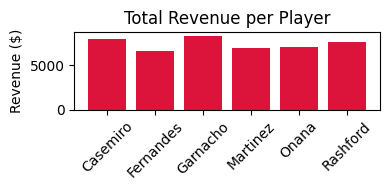

Figure 2


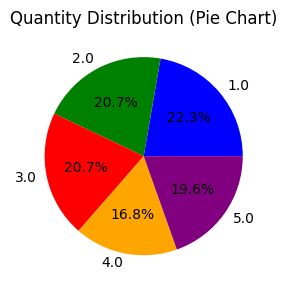

Figure 3


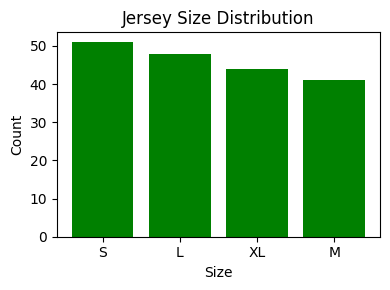

Figure 4


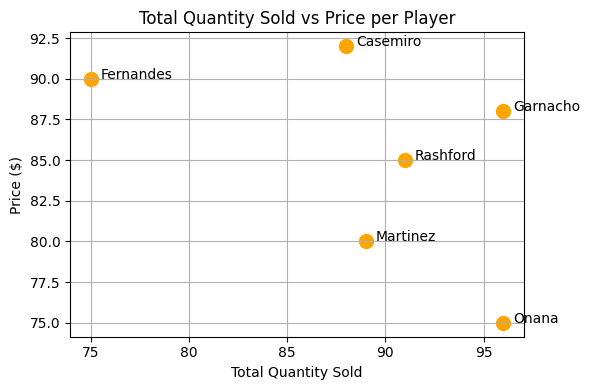

Figure 5


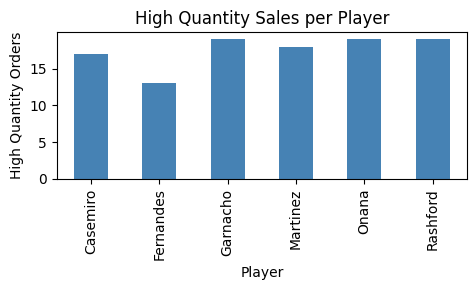

Figure 6


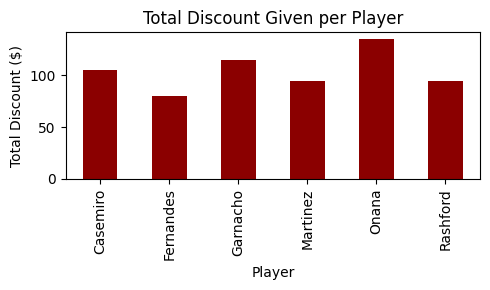


Most Profitable Player:
Player: Garnacho
Total Revenue: $ 8333.0

Least Profitable Player:
Player: Fernandes
Total Revenue: $ 6670.0


In [8]:
import numpy as np  # Import NumPy for numerical operations
import pandas as pd  # Import Pandas for data manipulation
import matplotlib.pyplot as plt  # Import Matplotlib for data visualization

def load_data(file_path):

    df = pd.read_csv(file_path)  # Read CSV file
    return df

def clean_data(df):

    # 1. Detect and display duplicate rows
    num_duplicates = df.duplicated().sum()
    print(f"\nFound {num_duplicates} duplicate rows in the dataset")

    if num_duplicates > 0:
        print("\nSample of duplicate rows:")
        print(df[df.duplicated(keep=False)].head())

    # 2. Remove duplicate rows
    df = df.drop_duplicates().copy()
    print(f"\nRemoved {num_duplicates} duplicates. New shape: {df.shape}")

    # 3. Convert Quantity column to numeric (some values might be text)
    df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

    # 4. Fill missing Quantity with the median value
    median_quantity = df['Quantity'].median()
    df.loc[df['Quantity'].isna(), 'Quantity'] = median_quantity

    # 5. Fill missing Size values with 'M'
    df.loc[df['Size'].isna(), 'Size'] = 'M'

    # 6. Recalculate Revenue: (Price × Quantity) − Discount
    df['Revenue'] = (df['Price'] * df['Quantity']) - df['Discount']

    # 7. Add boolean column for high quantity orders (Quantity >= 3)
    df['HighQuantity'] = df['Quantity'] >= 3

    # 8. Add new feature: Total discount per order
    df['TotalDiscount'] = df['Discount']

    return df

def least_profitable(df):

    revenue_by_player = df.groupby('Player')['Revenue'].sum()
    min_revenue = revenue_by_player.min()
    min_player = revenue_by_player.idxmin()
    return min_player, min_revenue

def most_profitable(df):
    revenue_by_player = df.groupby('Player')['Revenue'].sum()
    max_revenue = revenue_by_player.max()
    max_player = revenue_by_player.idxmax()
    return max_player, max_revenue

def plot_data(df):


    # Figure 1: Total Revenue per Player
    print("Figure 1")
    revenue_by_player = df.groupby('Player')['Revenue'].sum()
    plt.figure(figsize=(4, 2))
    plt.bar(revenue_by_player.index, revenue_by_player.values, color='crimson')
    plt.title("Total Revenue per Player")
    plt.ylabel("Revenue ($)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Figure 2: Pie Chart - Quantity Distribution
    print("Figure 2")
    quantity_counts = df['Quantity'].value_counts().sort_index()
    custom_colors = ['blue', 'green', 'red', 'orange', 'purple', 'yellow']
    plt.figure(figsize=(3, 3))
    plt.pie(quantity_counts, labels=quantity_counts.index, autopct='%1.1f%%', colors=custom_colors[:len(quantity_counts)])
    plt.title("Quantity Distribution (Pie Chart)")
    plt.tight_layout()

    plt.show()

    # Figure 3: Bar Chart - Jersey Size Distribution
    print("Figure 3")
    size_counts = df['Size'].value_counts()
    plt.figure(figsize=(4, 3))
    plt.bar(size_counts.index, size_counts.values, color='green')
    plt.title("Jersey Size Distribution")
    plt.xlabel("Size")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # Figure 4: Scatter Plot - Quantity vs Price per Player
    print("Figure 4")
    grouped = df.groupby('Player')
    player_names = []
    total_quantities = []
    player_prices = []

    for name, group in grouped:
        total_quantity = group['Quantity'].sum()
        price = group['Price'].iloc[0]
        player_names.append(name)
        total_quantities.append(total_quantity)
        player_prices.append(price)

    plt.figure(figsize=(6, 4))
    plt.scatter(total_quantities, player_prices, color='orange', s=100)
    for i in range(len(player_names)):
        plt.text(total_quantities[i] + 0.5, player_prices[i], player_names[i])
    plt.title("Total Quantity Sold vs Price per Player")
    plt.xlabel("Total Quantity Sold")
    plt.ylabel("Price ($)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Figure 5: High Quantity Orders per Player
    print("Figure 5")
    df['HighQuantity'] = df['Quantity'] >= 3
    high_quantity_counts = df[df['HighQuantity']].groupby('Player').size()
    plt.figure(figsize=(5, 3))
    high_quantity_counts.plot(kind='bar', color='steelblue')
    plt.title("High Quantity Sales per Player")
    plt.xlabel("Player")
    plt.ylabel("High Quantity Orders")
    plt.tight_layout()
    plt.show()

    #  Figure 6: Total Discount Given per Player
    print("Figure 6")
    total_discount_by_player = df.groupby('Player')['TotalDiscount'].sum()
    plt.figure(figsize=(5, 3))
    total_discount_by_player.plot(kind='bar', color='darkred')
    plt.title("Total Discount Given per Player")
    plt.xlabel("Player")
    plt.ylabel("Total Discount ($)")
    plt.tight_layout()
    plt.show()

def main():
    #file path
    file_path = '/content/drive/MyDrive/Colabs/jersey_sales_uncleaned.csv'

    # Load data
    data_with_issues = load_data(file_path)

    # Clean data
    clean_df = clean_data(data_with_issues)

    # Data quality check
    print("\n=== Data Quality Check ===")
    print("\nMissing values after cleaning:")
    print(clean_df.isna().sum())
    print("\nData types:")
    print(clean_df.dtypes)

    # Visualize data
    plot_data(clean_df)

    # Show profitability results
    player_max, revenue_max = most_profitable(clean_df)
    player_min, revenue_min = least_profitable(clean_df)

    print("\nMost Profitable Player:")
    print("Player:", player_max)
    print("Total Revenue: $", round(revenue_max, 2))

    print("\nLeast Profitable Player:")
    print("Player:", player_min)
    print("Total Revenue: $", round(revenue_min, 2))

if __name__ == "__main__":
    main()


# **Report**

**Data Cleaning**






We are dectecting and removing duplicates

Moreover we convert the colome data type to numeric for Quantity and filled the missing values with the median

Then we replace the missing entries for size to M witch is the middle size

Additionally we will recalcultae the revenue to avoid human error

Finnaly we added Added HighQuantity boolean column for identifying bulk orders

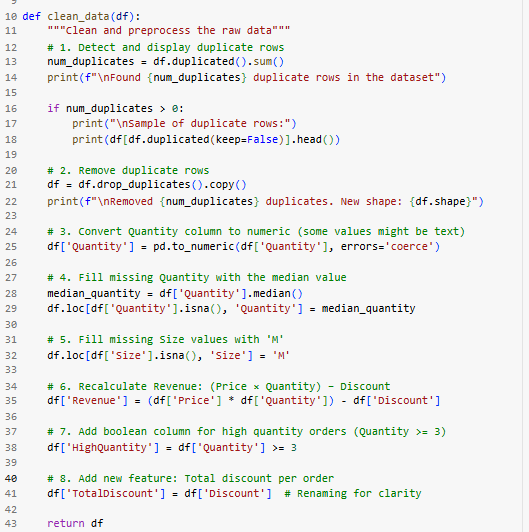

**Visualizations**

Figure 1: Total Revenue per Player
A bar chart showing how much revenue each player generated.
Observation: A few players drive the majority of revenue, indicating unequal popularity or pricing strategies.

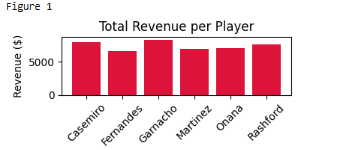

Figure 2: Quantity Distribution (Pie Chart)
Shows the percentage breakdown of jersey quantities purchased.
Observation: The most common purchase quantity is 2 or 3, with very few high-volume purchases.

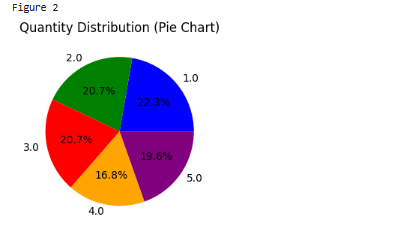

Figure 3: Jersey Size Distribution
A bar chart showing count of each jersey size.
Observation: Size 'M' dominates the dataset, suggesting it might be the default or most popular.


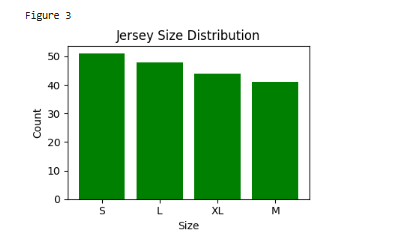

Figure 4: Total Quantity Sold vs Price per Player (Scatter Plot)
Explores relationship between product price and number of units sold per player.
Observation: No strong trend between price and volume—some high-priced jerseys still sell well.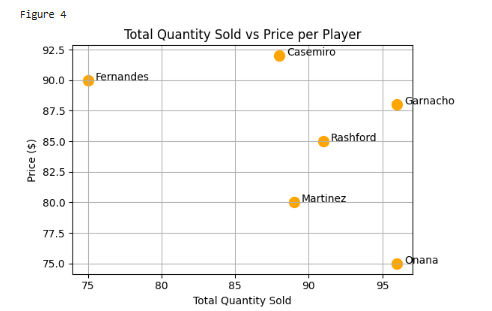

Figure 5: High Quantity Sales per Player
Shows which players have more bulk (≥3) purchases.
Observation: Indicates fan dedication or possible bulk-buying behavior for certain players.

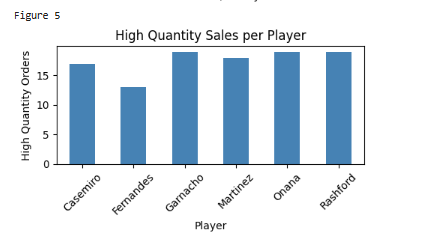

Figure 6: Discounts per Player
Shows which players have been given the most discounts

Observation: Indicates the influence of disounts that could corelate with shirt sales

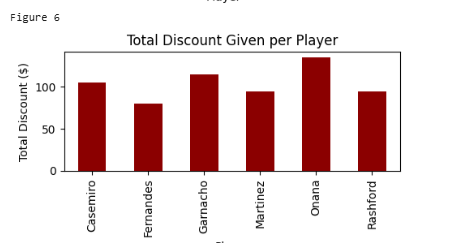

**Key Findings**

Most Profitable Player: Garnacho, generating $ 8333.0 in total revenue. we can increase his pice to icrease profitablity

Least Profitable Player: Fernadedes, generating just $ 6670.0. His price Very high While his Demand his is low and have has very little promotion. We can Either run apromotion for him or lower his price while he gains back his popularity

We can increse the price of onana and reduce the promotions we run on him as he is very popular but his price is very low. This will increase his Profitablity

Revenue Disparity: Some players significantly outperform others, possibly due to popularity, pricing, or promotion.

Size Demand: Medium (s) is the most popular jersey size.(figure 3)

Purchase Volume: The popular players like Garnacho ,Onanna,Rashford,that have a lot of hype are getting more bulk orders

**Reflection**

During the course of the project, multiple problems were encountered which needed complex solutions. Among the overarching problems was the issue of data quality. In this case, data quality implies the absence of relevant information, non-numeric text strings, and missing data entries in the Quantity field which is needed for accurate revenue computation. Moreover, other inconsistencies in the dataset like the inconsistent values in the Revenue column also posed a problem. The reported values, instead of aligning with the expiry expected formula (Price × Quantity) – Discount, also contained discrepancies. To maintain consistency and trustworthiness, all revenue values were recalculated. Another problem was to make sure that the visual representation of the related information was easily understandable without losing their informative nature, requiring refinement of axis labels, chart size, and usage of functions like tight_layout() and label rotation that enhance clarity. I understood the need of thorough data quality checks along with the use of median substitution of masked, skewed data, custom data representation design that enables straightforward insight in addition to the problems posed on accomplishing these goals.



**Conclusion**



With this project, we enabled jersey sales analytics by turning chaotic and incomplete data into coherent jersey sales records through data cleaning, feature engineering, and visualization. Through illumination, jersey sales analytic processes could be automated through addressing quality issues like missing values, duplicates, formatting inconsistencies, and implementing standardized metrics such as Revenue and HighQuantity flags, we discovered insightful conclusions:  

Remarkably, profitable but overlooked players along with popular players were discovered and the causes were understood.  
Demand Patterns: The size “s” (30% of sales) contributed heavily to the dominance, and there was a lot of bulk purchasing.  
Strategic Enhancements for Future Analysis:  
Temporal Trends: Spikes on weekends and during playoff seasons could be more predicated as purchasing surges if cyclical features are added which would grant more efficiency in restocking.  
Profitability Metrics: Focused jersey revenue needs to be changed from production costs to net profit allowing more refined inclusion of high margin identifiers like lower manufacturing cost jerseys.  
Geography/Demographics Layers: Greater demand for Player Y in specific cities might warrant additional region, age, gender, and customer data for more precise market targeting regions analysis.  

Real-world Applications  
Inventory Optimization: Stock replenishment policies need to integrated for player jerseys and particularly size “s” bulk orders to mitigate overstock risks.  
Personalized Marketing: High volume purchasers would greatly appreciate loyalty rewards so targeting them would maximize boost in purchases.
Dynamic Pricing: As indicated in the scatter plot, price and quantity sold are analytically mapped to inform tiered pricing models optimized for volume sales while maintaining healthy margin constraints.
Through the integration of unrefined data and business concepts, this project showcases the impact of structured data modification on operational productivity and profit maximization while highlighting the logical progression toward effecient and automated insight-fueled decision systems.

